In [9]:
#setup notebook
%load_ext autoreload
%autoreload 2
%matplotlib inline
import logging
logging.basicConfig(format='%(asctime)s %(levelname)s:%(message)s', level=logging.INFO, datefmt='%I:%M:%S')
from sdata.sclass.process_graph import ProcessGraph, get_process_graph

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [10]:
from sdata.sclass.process import sclass, processdata_class_factory, create_process_class
from sdata.sclass.process import create_process_class, create_composite_process_class, ProcessData, ProcessNode, CompositeProcess

material = sclass("Material")
material

sdata.sclass.process.Material

In [11]:
sclass("LSDynaMesh")

sdata.sclass.process.LSDynaMesh

In [12]:
sclass("LSDynaMesh").__bases__

(sdata.sclass.process.ProcessData,)

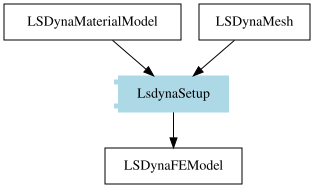

In [13]:
LsdynaSetup = create_process_class("LsdynaSetup", 
                              {"LSDynaMesh":sclass("LSDynaMesh"), "LSDynaMaterialModel":sclass("LSDynaMaterialModel")}, 
                              {"LSDynaFEModel":sclass("LSDynaFEModel")})
get_process_graph([LsdynaSetup])

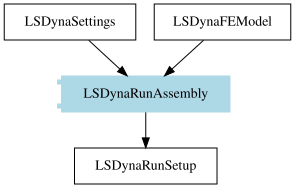

In [14]:
LSDynaRunAssembly = create_process_class("LSDynaRunAssembly", 
                              {"LSDynaFEModel":sclass("LSDynaFEModel"), "LSDynaSettings":sclass("LSDynaSettings")}, 
                              {"LSDynaRunSetup":sclass("LSDynaRunSetup")})
get_process_graph([LSDynaRunAssembly])

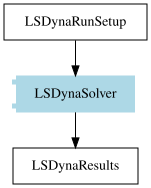

In [15]:
LSDynaSolver = create_process_class("LSDynaSolver", 
                              {"LSDynaRunSetup":sclass("LSDynaRunSetup")}, 
                              {"LSDynaResults":sclass("LSDynaResults")})
get_process_graph([LSDynaSolver])

In [6]:
get_process_graph([LSDynaRunAssembly, LSDynaSolver])

NameError: name 'LSDynaRunAssembly' is not defined

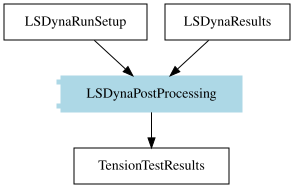

In [8]:
LSDynaPostProcessing = create_process_class("LSDynaPostProcessing", 
                              {"LSDynaResults":sclass("LSDynaResults"), "LSDynaRunSetup":sclass("LSDynaRunSetup")}, 
                              {"TensionTestResults":sclass("TensionTestResults")})
get_process_graph([LSDynaPostProcessing])

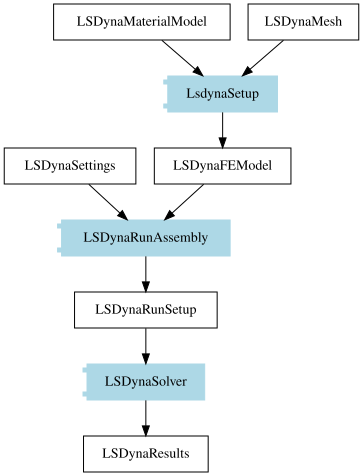

In [10]:
get_process_graph([LSDynaRunAssembly, LSDynaSolver, LsdynaSetup])

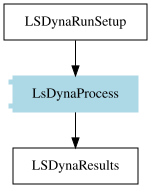

In [11]:
LsDynaProcess = create_composite_process_class("LsDynaProcess", [LSDynaSolver])
get_process_graph([LsDynaProcess])

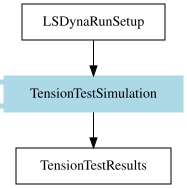

In [12]:
TensionTestSimulation = create_composite_process_class("TensionTestSimulation", [LsDynaProcess, LSDynaPostProcessing])
get_process_graph([TensionTestSimulation])

In [13]:
TensionTestSimulation.__bases__

(sdata.sclass.process.ProcessNode,)

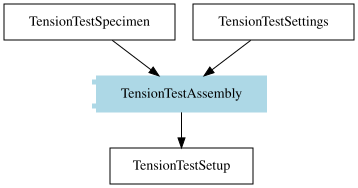

In [14]:
TensionTestAssembly = create_process_class("TensionTestAssembly", 
                              {"TensionTestSpecimen":sclass("TensionTestSpecimen"), "TensionTestSettings":sclass("TensionTestSettings")}, 
                              {"TensionTestSetup":sclass("TensionTestSetup")})
get_process_graph([TensionTestAssembly])

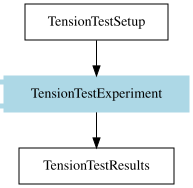

In [15]:
TensionTestExperiment = create_process_class("TensionTestExperiment", 
                              {"TensionTestSetup":sclass("TensionTestSetup")}, 
                              {"TensionTestResults":sclass("TensionTestResults")})
get_process_graph([TensionTestExperiment])

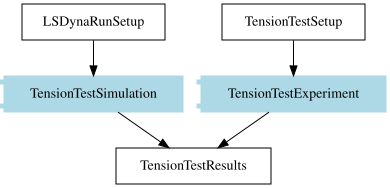

In [16]:
get_process_graph([TensionTestExperiment, TensionTestSimulation])

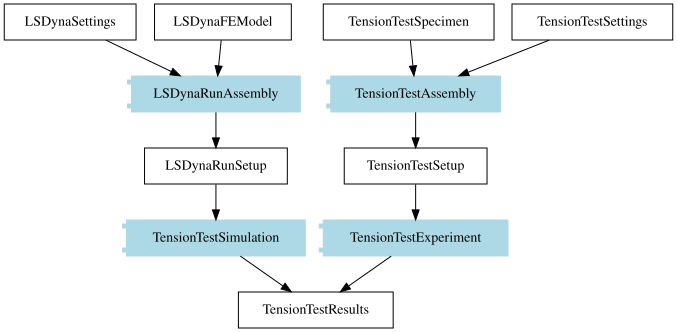

In [17]:
get_process_graph([TensionTestExperiment, TensionTestSimulation, TensionTestAssembly, LSDynaRunAssembly])

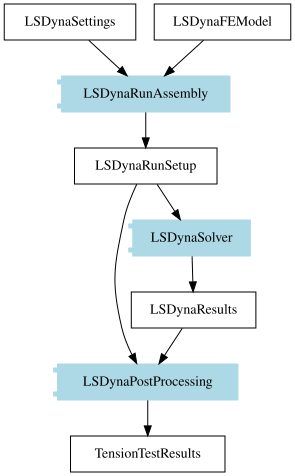

In [18]:
get_process_graph([LSDynaRunAssembly, LSDynaSolver, LSDynaPostProcessing])

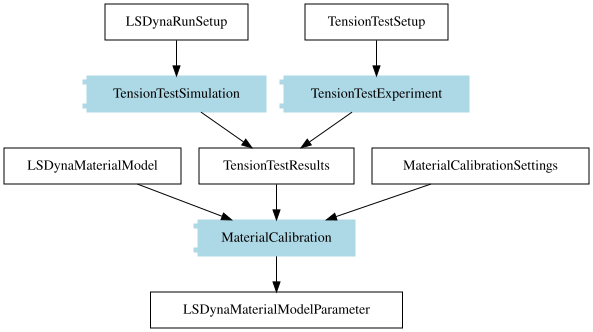

In [19]:
materialcalibration = create_process_class("MaterialCalibration", 
                              {"TensionTestResults":sclass("TensionTestResults"), 
                               "LSDynaMaterialModel":sclass("LSDynaMaterialModel"), 
                               "MaterialCalibrationSettings":sclass("MaterialCalibrationSettings")}, 
                              {"LSDynaMaterialModelParameter":sclass("LSDynaMaterialModelParameter")})
get_process_graph([materialcalibration, TensionTestSimulation, TensionTestExperiment])

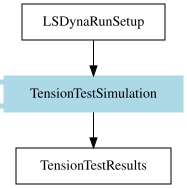

In [20]:
from sdata.sclass.process_graph import ProcessGraph
from IPython.display import display, SVG

g = ProcessGraph()
g.add_process(TensionTestSimulation)


dot_graph = g.to_graphviz(name="CombinedProcess", rankdir="TD", collapsed=True)

display(SVG(dot_graph.pipe(format='svg')))

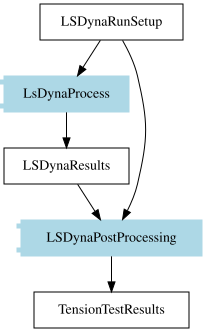

In [21]:
from sdata.sclass.process_graph import ProcessGraph, get_process_graph
from IPython.display import display, SVG

g = ProcessGraph()
for process in TensionTestSimulation.processes:
    g.add_process(process)

dot_graph = g.to_graphviz(name="CombinedProcess", rankdir="TD", collapsed=True)

display(SVG(dot_graph.pipe(format='svg')))

In [65]:
sclass("Onnx")(name="Otto123", project="dp2g").metadata.df

,name,value,unit,dtype,description,label,required,ontology
key,,,,,,,,
_sdata_class,_sdata_class,sdata.sclass.process:Onnx,-,str,sdata class,,True,
_sdata_ctime,_sdata_ctime,2025-09-23T15:55:04.998320+00:00,-,str,UTC creation date,,False,
_sdata_name,_sdata_name,Otto123,-,str,name of the data object,,True,
_sdata_parent_sname,_sdata_parent_sname,SUUID__dp2g__5926d7d997945e9c9a3277304f2437cf,-,str,sname of the parent,,False,
_sdata_project_sname,_sdata_project_sname,Project__dp2g__74860622a0aa50d6b52950ecc9c8bdf2,-,str,sname of the project,,False,
_sdata_sname,_sdata_sname,Onnx__otto123__31a97ec7510e54a1b248b46776683409,-,str,sname of the data object,,True,
_sdata_suuid,_sdata_suuid,MzFhOTdlYzc1MTBlNTRhMWIyNDhiNDY3NzY2ODM0MDlPbm...,-,str,Super Universally Unique Identifier,,True,
_sdata_topology_class,_sdata_topology_class,sdata.sclass:GenericallyDependentContinuant,-,str,sdata bfo class name,,True,
_sdata_version,_sdata_version,1.0.0,-,str,sdata package version,,True,


In [ ]:
class Onnx(Base):
    def predict